# 01b — Load & Inspect (fixed variant)

**Stage 1 of 3 (fixed).** Same as `01_load_and_inspect.ipynb` but uses `wesad_preprocess_fixed`.

> This variant fixes the ACC FIR filter (axis + per-rate cutoff). See `wesad_preprocess_fixed.py`.

In [1]:
import sys
from pathlib import Path
HERE = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Scripts' / 'Preprocess').exists()) / 'Scripts' / 'Preprocess'
sys.path.insert(0, str(HERE))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wesad_preprocess_fixed as wp

SUBJECT_ID = 3   # change to inspect another subject: 2-11, 13-17

## 1. Load the subject

In [2]:
data = wp.load_subject(SUBJECT_ID)
print('Top-level keys :', list(data.keys()))
print('Chest keys     :', list(data['signal']['chest'].keys()))
print('Wrist keys     :', list(data['signal']['wrist'].keys()))
pd.DataFrame(wp.describe_subject(data))

Top-level keys : ['signal', 'label', 'subject']
Chest keys     : ['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp']
Wrist keys     : ['ACC', 'BVP', 'EDA', 'TEMP']


,location,signal,shape,fs_hz,duration_s
0,chest,ACC,"(4545100, 3)",700,6493.0
1,chest,ECG,"(4545100, 1)",700,6493.0
2,chest,EMG,"(4545100, 1)",700,6493.0
3,chest,EDA,"(4545100, 1)",700,6493.0
4,chest,Temp,"(4545100, 1)",700,6493.0
5,chest,Resp,"(4545100, 1)",700,6493.0
6,wrist,ACC,"(207776, 3)",32,6493.0
7,wrist,BVP,"(415552, 1)",64,6493.0
8,wrist,EDA,"(25972, 1)",4,6493.0
9,wrist,TEMP,"(25972, 1)",4,6493.0


## 2. Label distribution (original WESAD ids, 700 Hz)

Only 1 (baseline), 2 (stress) and 3 (amusement) are kept later; 0/4–7 are dropped in stage 3.

In [3]:
labels = np.asarray(data['label']).ravel()
ids, counts = np.unique(labels, return_counts=True)
pd.DataFrame({'label_id': ids,
              'meaning': [wp.WESAD_LABELS.get(i, '?') for i in ids],
              'samples': counts,
              'minutes': np.round(counts / wp.FS['label'] / 60, 2)})

,label_id,meaning,samples,minutes
0,0,transient,2345699,55.85
1,1,baseline,798000,19.00
2,2,stress,448000,10.67
3,3,amusement,262500,6.25
4,4,meditation,546001,13.00
5,5,ignore,51100,1.22
6,6,ignore,46900,1.12
7,7,ignore,46900,1.12


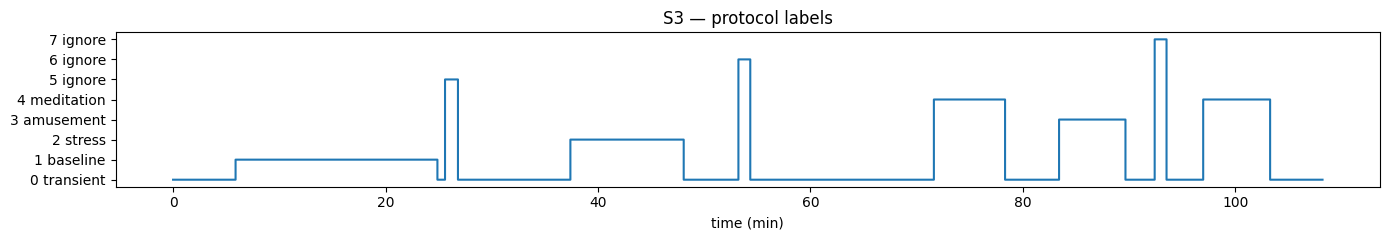

In [4]:
t = np.arange(len(labels)) / wp.FS['label'] / 60
plt.figure(figsize=(14, 2.5))
plt.plot(t[::700], labels[::700], drawstyle='steps-post')
plt.yticks(range(8), [f'{i} {wp.WESAD_LABELS[i]}' for i in range(8)])
plt.xlabel('time (min)'); plt.title(f'S{SUBJECT_ID} — protocol labels'); plt.tight_layout(); plt.show()

## 3. Plot raw signals

Signals are downsampled for plotting only (every `step`-th sample).

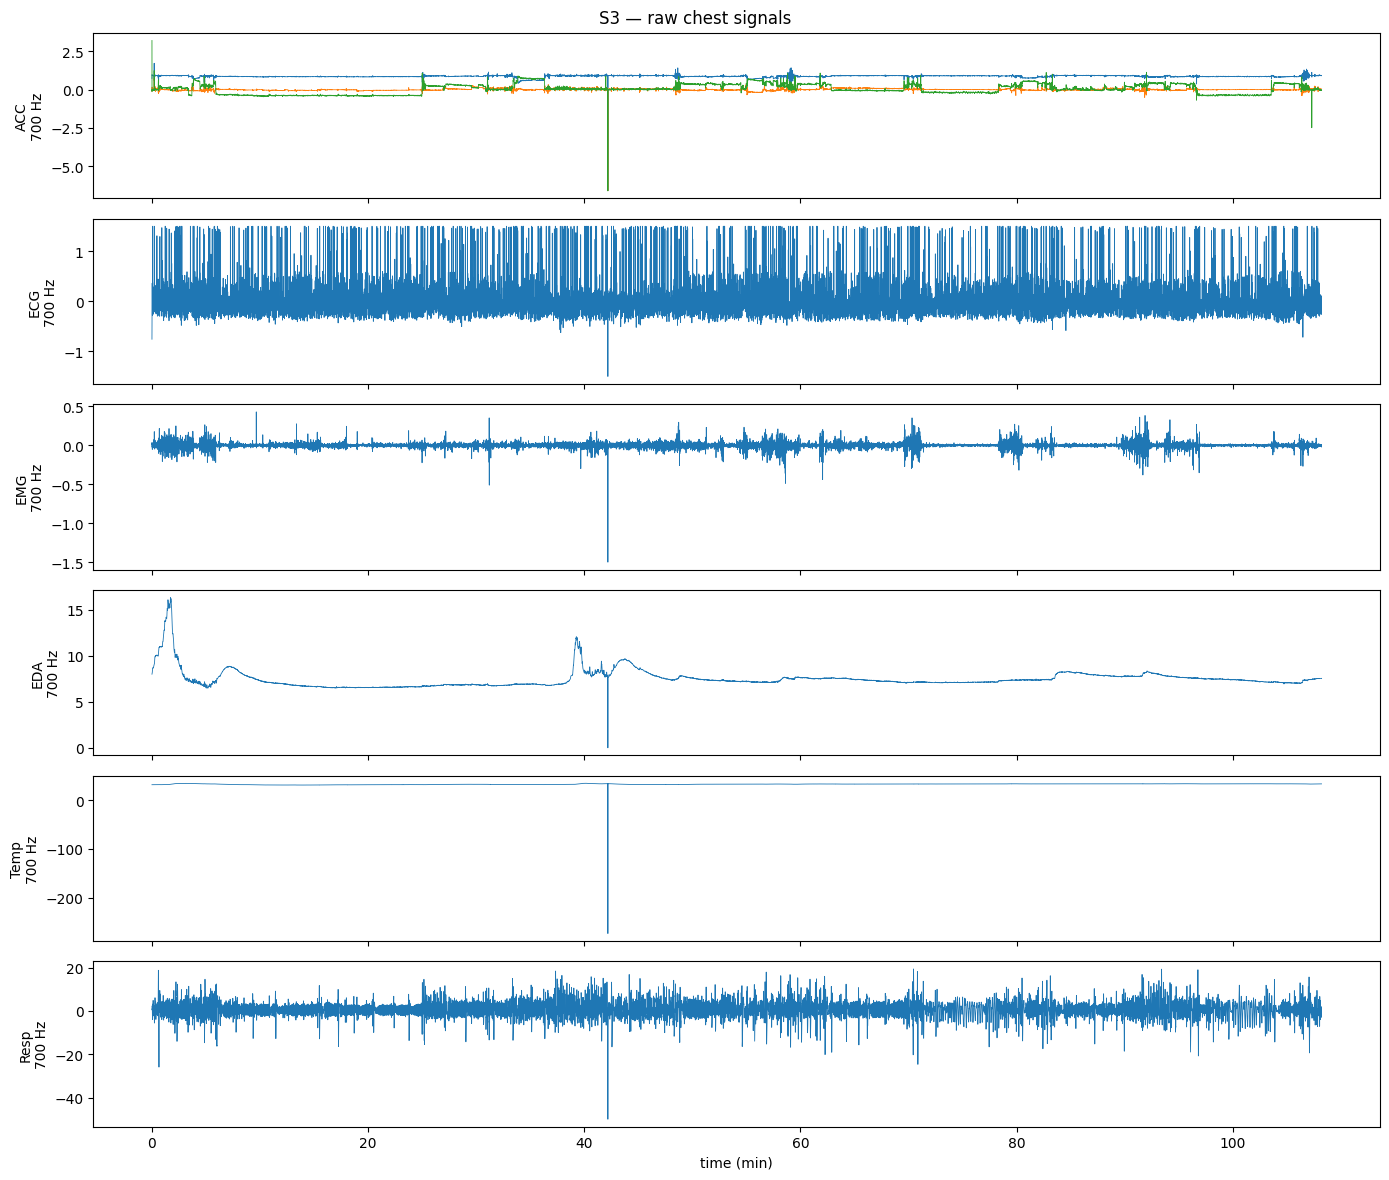

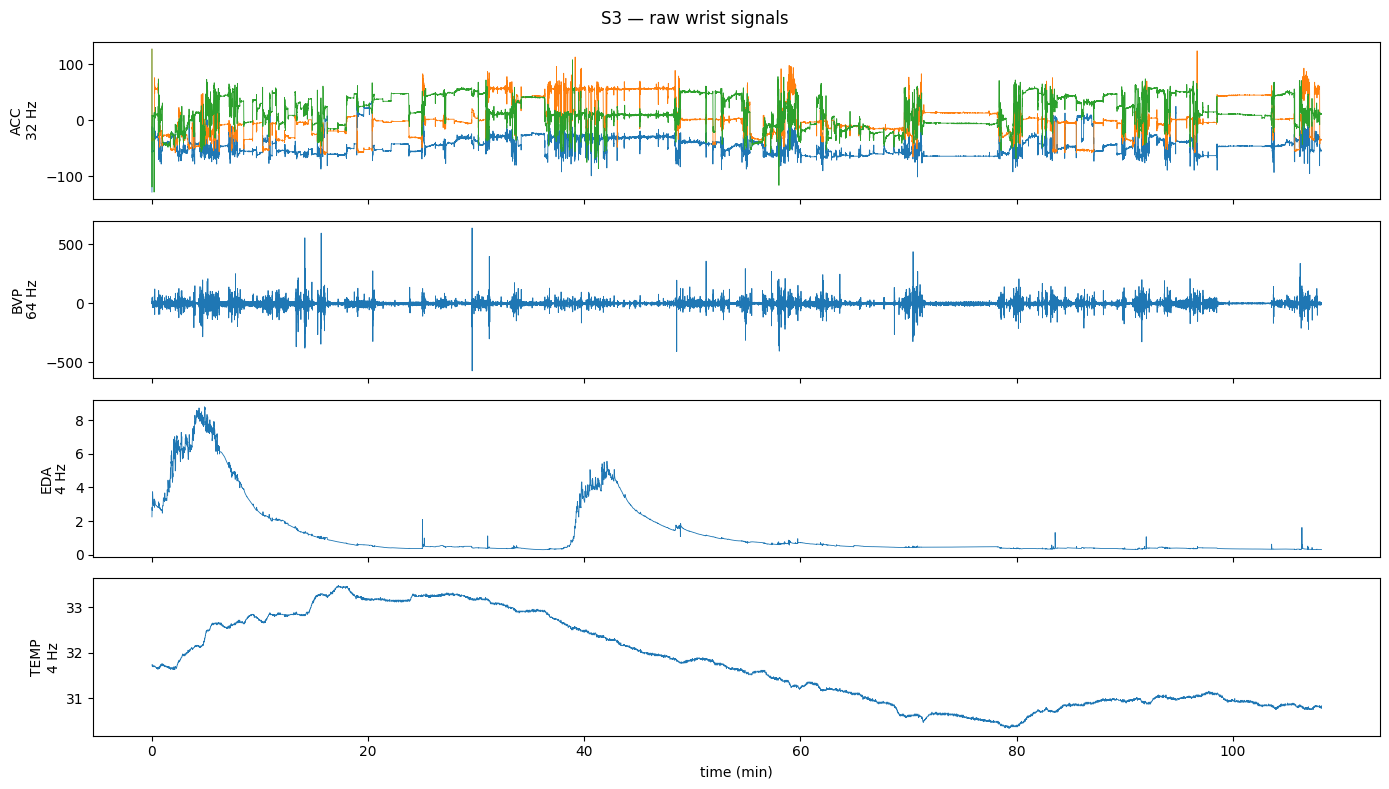

In [5]:
def plot_location(loc, max_points=20_000):
    sig = data['signal'][loc]
    fig, axes = plt.subplots(len(sig), 1, figsize=(14, 2.0 * len(sig)), sharex=True)
    for ax, (name, arr) in zip(axes, sig.items()):
        arr = np.asarray(arr)
        fs = wp.FS[loc][name]
        step = max(1, len(arr) // max_points)
        tt = np.arange(0, len(arr), step) / fs / 60
        ax.plot(tt, arr[::step], lw=0.6)
        ax.set_ylabel(f'{name}\n{fs} Hz')
    axes[-1].set_xlabel('time (min)')
    fig.suptitle(f'S{SUBJECT_ID} — raw {loc} signals'); fig.tight_layout(); plt.show()

plot_location('chest')
plot_location('wrist')

## 4. Synchronization sanity check

All signals should cover the same duration (chest/label at 700 Hz, wrist at lower rates).

In [6]:
df = pd.DataFrame(wp.describe_subject(data))
print('Duration spread (s):', df['duration_s'].max() - df['duration_s'].min())
df.sort_values('duration_s')

Duration spread (s): 0.0


,location,signal,shape,fs_hz,duration_s
0,chest,ACC,"(4545100, 3)",700,6493.0
1,chest,ECG,"(4545100, 1)",700,6493.0
2,chest,EMG,"(4545100, 1)",700,6493.0
3,chest,EDA,"(4545100, 1)",700,6493.0
4,chest,Temp,"(4545100, 1)",700,6493.0
5,chest,Resp,"(4545100, 1)",700,6493.0
6,wrist,ACC,"(207776, 3)",32,6493.0
7,wrist,BVP,"(415552, 1)",64,6493.0
8,wrist,EDA,"(25972, 1)",4,6493.0
9,wrist,TEMP,"(25972, 1)",4,6493.0


In [7]:
del data  # free memory before moving on